# Anexo B — Análisis y modelización revisados
Peng Chen · 13/09/2026

La propuesta se mantiene: análisis europeo, foco en España y predicción de rating. Madrid es una extensión de negocio. El notebook muestra resultados guardados y permite reproducir el entrenamiento con la opción explícita siguiente. Las métricas proceden de entrenar.py, ejecutado en esta revisión; no se importan métricas de la versión anterior.

In [1]:
from pathlib import Path
import json, sys, hashlib
BASE = Path.cwd()
if BASE.name == 'entrega': BASE = BASE.parent
elif BASE.name == 'TFM': BASE = BASE / 'revision_academica'
assert (BASE / 'src/entrenar.py').exists()
sys.path.insert(0,str(BASE / 'src'))
REENTRENAR = False  # True reproduce ajuste y evaluación, requiere el CSV de entrada.
if REENTRENAR:
    from entrenar import main
    main()
r = json.loads((BASE/'resultados/evaluacion.json').read_text())
print('Versión:',r['version'])
print('Partición:',r['split'])
print('SHA-256 entrada:',r['source_sha256'])


Versión: rating-2026-09-13-v2
Partición: {'train': 48789, 'validation': 16263, 'test': 16263}
SHA-256 entrada: 189a0531f12db609bdf5b35c7b707b6d1a977c3157b49aa818ae0a1499611b5e


## EDA territorial
Etiquetas originales: England, Scotland, Wales y Northern Ireland se mantienen separadas. Frecuencia de registros no equivale a tamaño completo de mercado. Las medias no están ajustadas por composición.

In [2]:
import pandas as pd
pd.read_json(BASE/'resultados/eda_paises.json').sort_values('n',ascending=False)


,country,n,rating_n,rating_mean
6,England,24090,22914,3.946954
8,France,13300,12676,3.982368
9,Germany,9431,8836,4.062472
20,Spain,8295,7758,3.997809
13,Italy,7314,6984,3.900344
22,The Netherlands,3801,3562,4.047305
21,Sweden,2498,2312,3.908953
1,Belgium,2267,2146,3.942451
18,Scotland,2201,2101,3.894098
16,Portugal,1823,1665,4.165165


## Protocolo
60/20/20, estratificación por país y semilla fija. Preparación ajustada en entrenamiento. Algoritmo elegido con RMSE de validación; reajuste en 80% y evaluación de test una vez por variante. Hiperparámetros prefijados. La base ya fue explorada: no es validación externa. No se aíslan cadenas ni periodos.

La ablación se compara por algoritmo en validación. En test se muestran variantes seleccionadas con algoritmos distintos; la diferencia final no se atribuye exclusivamente a las variables.

In [3]:
pd.DataFrame(r['validation'])[['conjunto','modelo','n','RMSE','MAE','R2','segundos']]


,conjunto,modelo,n,RMSE,MAE,R2,segundos
0,sin_reputacion,Media,16263,0.681158,0.501265,-0.000026,0.18
1,sin_reputacion,Lineal,16263,0.633160,0.478227,0.135944,0.86
2,sin_reputacion,RandomForest,16263,0.620113,0.460245,0.171186,11.93
3,sin_reputacion,XGBoost,16263,0.620507,0.463039,0.170133,0.43
4,con_reputacion,Media,16263,0.681158,0.501265,-0.000026,0.24
5,con_reputacion,Lineal,16263,0.542331,0.371272,0.366065,1.80
6,con_reputacion,RandomForest,16263,0.534527,0.354989,0.384180,31.86
7,con_reputacion,XGBoost,16263,0.533142,0.357351,0.387365,0.57


In [4]:
pd.DataFrame({k:{a:b for a,b in v.items() if a!='baseline_media'} for k,v in r['test'].items()}).T


,n,RMSE,MAE,R2,fuera_1_5
sin_reputacion,16263.0,0.624743,0.461864,0.192877,0.0
con_reputacion,16263.0,0.542340,0.360654,0.391751,0.0


## Error por territorio e incertidumbre
No son pruebas de causalidad o transferencia a territorios nuevos. El bootstrap remuestrea errores del mismo test y no incluye deriva, cadenas o selección del modelo.

In [5]:
pd.DataFrame(r['country_test']['sin_reputacion']).T.sort_values('n',ascending=False)


,n,RMSE,MAE,R2,fuera_1_5
England,4583.0,0.657320,0.470131,0.219721,0.0
France,2535.0,0.618601,0.461350,0.193700,0.0
Germany,1767.0,0.583721,0.449061,0.104510,0.0
Spain,1552.0,0.639893,0.478452,0.236824,0.0
Italy,1397.0,0.515493,0.388433,0.214646,0.0
The Netherlands,713.0,0.597696,0.444070,0.116751,0.0
Sweden,463.0,0.675588,0.521068,0.025253,0.0
Belgium,429.0,0.569107,0.435451,0.112563,0.0
Scotland,420.0,0.695964,0.517753,0.236132,0.0
Portugal,333.0,0.600962,0.459864,0.154602,0.0


In [6]:
pd.DataFrame(r['bootstrap']).T


,MAE_bootstrap_p025,MAE_bootstrap_p975,nota
sin_reputacion,0.455385,0.468266,Incertidumbre condicional del test; no incluye...
con_reputacion,0.354624,0.366852,Incertidumbre condicional del test; no incluye...


## Interpretación en validación
Permutación individual en 1.200 filas y 3 repeticiones. Importancia positiva implica mayor error al desordenar; no mide el retorno de intervenir. Correlaciones entre variables pueden ocultar o repartir importancia.

sin_reputacion


,feature,delta_RMSE,std
0,cuisine_chinese,0.032469,0.003260
1,vegan_options,0.023585,0.001237
2,open_days_per_week,0.020017,0.000499
3,longitude,0.014738,0.003490
4,vegetarian_friendly,0.012279,0.000550
5,open_hours_per_week,0.005076,0.001536
6,cuisine_indian,0.004492,0.000760
7,gluten_free,0.003215,0.000707


con_reputacion


,feature,delta_RMSE,std
0,food,0.053590,0.003519
1,service,0.042754,0.001234
2,value,0.011497,0.000326
3,open_days_per_week,0.011241,0.000381
4,cuisine_chinese,0.009344,0.001617
5,log_reviews_count,0.008212,0.002135
6,vegan_options,0.005504,0.000925
7,longitude,0.003995,0.000768


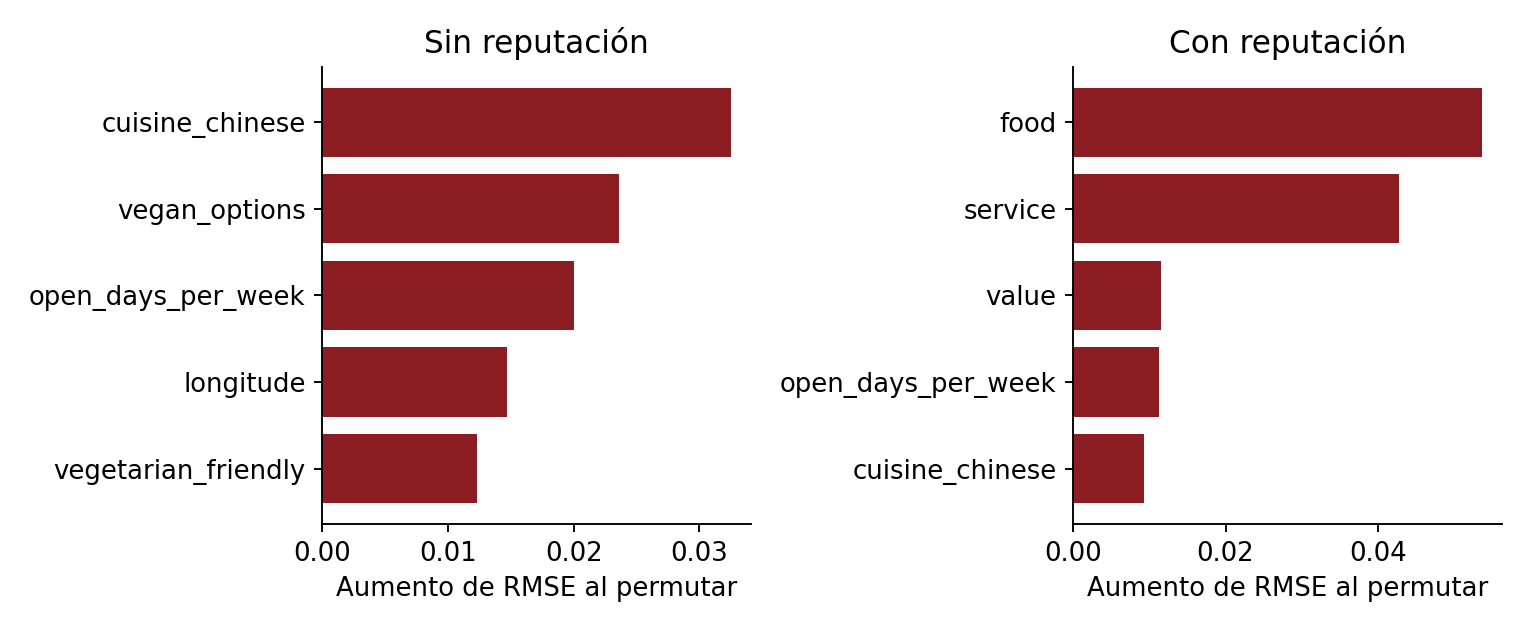

In [7]:
from IPython.display import display, Image
for k in r['permutation_validation']:
    print(k)
    display(pd.DataFrame(r['permutation_validation'][k]).head(8))
display(Image(filename=str(BASE/'resultados/interpretacion.png')))


## Contrato del demostrador
Se despliega localmente la variante sin reputación por su conjunto de entradas. El ejemplo es histórico y no tiene nombre, aunque sus coordenadas pueden identificar el establecimiento. El error medio agregado no es un intervalo individual.

In [8]:
from servir import Predictor
modelo=Predictor()
entrada=json.loads((BASE/'resultados/ejemplo_entrada.json').read_text())
modelo.predict(entrada)


{'rating_estimado': 3.7226705511566696,
 'version': 'rating-2026-09-13-v2',
 'modelo': 'RandomForest',
 'MAE_test_historico': 0.4618643326998886,
 'advertencias': ['Campos desconocidos imputados dentro del pipeline: open_days_per_week, open_hours_per_week, working_shifts_per_week',
  'Estimación transversal sobre datos de 2021; no valida nuevas aperturas ni rentabilidad.']}

## Fuentes y conclusiones
Dataset de Stefano Leone, Kaggle, versión 1, licencia declarada CC0 verificada en metadatos. Ver DERECHOS_DATOS.md. El modelo mejora la referencia histórica, con utilidad empresarial todavía por validar. No demuestra demanda futura ni rentabilidad de un buffet en Madrid. Los anexos de Madrid documentan fuentes actuales y escenarios separados del modelo.

Los archivos fuente siguientes forman parte del código entregado y permiten revisar las decisiones de implementación.

## Código: entrenar.py

```python
"""Revisión reproducible: selección en validación, evaluación final y ablación.
No pronostica futuras aperturas: estimación transversal de rating histórico.
"""
from pathlib import Path
import hashlib, json, time, platform
import numpy as np
import pandas as pd
import joblib, sklearn, xgboost
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

BASE=Path(__file__).resolve().parents[1]
OUT=BASE/'resultados'
SOURCE=BASE.parent/'data/asian_restaurants_europe.csv'
SEED=20260913
NUM=['latitude','longitude','open_days_per_week','open_hours_per_week','working_shifts_per_week']
CAT=['country','region','price_level','vegetarian_friendly','vegan_options','gluten_free']
CUISINES=['Chinese','Japanese','Thai','Korean','Vietnamese','Indian','Asian','Sushi','Dim Sum','Ramen','Noodles']
BIN=['cuisine_'+x.lower().replace(' ','_') for x in CUISINES]
POST=['food','service','value','atmosphere','log_reviews_count']

def features(df):
    x=df[NUM+CAT].copy()
    for c in NUM: x[c]=pd.to_numeric(x[c],errors='coerce')
    for c in CAT: x[c]=x[c].where(x[c].notna(),np.nan)
    tokens=df.cuisines.fillna('').map(lambda s:{v.strip().lower() for v in s.split(',')})
    for cuisine,col in zip(CUISINES,BIN): x[col]=tokens.map(lambda s:int(cuisine.lower() in s))
    for c in POST[:4]: x[c]=pd.to_numeric(df[c],errors='coerce')
    x['log_reviews_count']=np.log1p(pd.to_numeric(df.total_reviews_count,errors='coerce').clip(lower=0))
    return x

def pipeline(model,post):
    numeric=NUM+BIN+(POST if post else [])
    prep=ColumnTransformer([
        ('num',Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),('scale',StandardScaler())]),numeric),
        ('cat',Pipeline([('impute',SimpleImputer(strategy='constant',fill_value='Unknown')),('encode',OneHotEncoder(handle_unknown='ignore'))]),CAT)])
    return Pipeline([('prep',prep),('model',model)])

def metrics(y,p):
    return {'n':len(y),'RMSE':float(np.sqrt(mean_squared_error(y,p))),'MAE':float(mean_absolute_error(y,p)),
            'R2':float(r2_score(y,p)),'fuera_1_5':int(((p<1)|(p>5)).sum())}

def main():
    OUT.mkdir(exist_ok=True)
    df=pd.read_csv(SOURCE,low_memory=False)
    raw_n=len(df)
    # Keep restaurant identity before any transformations or splits.
    assert df.restaurant_link.notna().all()
    dup=int(df.restaurant_link.duplicated().sum())
    df=df.drop_duplicates('restaurant_link').copy()
    countries=df.groupby('country').agg(n=('restaurant_link','size'),rating_n=('avg_rating','count'),rating_mean=('avg_rating','mean')).reset_index()
    countries.to_json(OUT/'eda_paises.json',orient='records',indent=2,force_ascii=False)
    audit={'filas_asia':raw_n,'duplicados_id':dup,'etiquetas_geograficas':int(df.country.nunique()),'sin_rating':int(df.avg_rating.isna().sum()),
      'espana_n':int(df.country.eq('Spain').sum()),'missing_pct':(df.isna().mean()*100).to_dict(),
      'nota_geografica':'24 etiquetas; England, Scotland, Wales y Northern Ireland se mantienen separadas, no son 24 estados soberanos.'}
    df=df[df.avg_rating.between(1,5)].reset_index(drop=True)
    idx=np.arange(len(df))
    trainval,test=train_test_split(idx,test_size=.2,random_state=SEED,stratify=df.country)
    train,val=train_test_split(trainval,test_size=.25,random_state=SEED,stratify=df.iloc[trainval].country)
    assert not(set(train)&set(val) or set(train)&set(test) or set(val)&set(test))
    x=features(df);y=df.avg_rating
    split={str(i):'train' for i in train}
    split.update({str(i):'validation' for i in val});split.update({str(i):'test' for i in test})
    (OUT/'particiones.json').write_text(json.dumps(split))
    source_sha=hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    comparisons=[];finals={};selected={};perms={};country_errors={};boot={}
    models={'Media':DummyRegressor(),'Lineal':LinearRegression(),
      'RandomForest':RandomForestRegressor(n_estimators=100,max_depth=16,min_samples_leaf=8,max_features=.8,n_jobs=4,random_state=SEED),
      'XGBoost':XGBRegressor(n_estimators=220,max_depth=4,learning_rate=.06,subsample=.85,colsample_bytree=.85,n_jobs=4,random_state=SEED,objective='reg:squarederror')}
    for name,post in [('sin_reputacion',False),('con_reputacion',True)]:
        cols=NUM+BIN+CAT+(POST if post else [])
        fitted={}
        for model_name,model in models.items():
            from sklearn.base import clone
            start=time.time();p=pipeline(clone(model),post)
            p.fit(x.iloc[train][cols],y.iloc[train])
            pred=p.predict(x.iloc[val][cols]);m=metrics(y.iloc[val],pred)
            comparisons.append({'conjunto':name,'modelo':model_name,**m,'segundos':round(time.time()-start,2)})
            fitted[model_name]=p
            print(name,model_name,m,flush=True)
        best=min([r for r in comparisons if r['conjunto']==name],key=lambda r:r['RMSE'])['modelo']
        selected[name]=best
        # Interpretation uses validation; test remains untouched during selection.
        sample=np.random.default_rng(SEED).choice(val,size=min(1200,len(val)),replace=False)
        importance=permutation_importance(fitted[best],x.iloc[sample][cols],y.iloc[sample],n_repeats=3,random_state=SEED,scoring='neg_root_mean_squared_error',n_jobs=2)
        perms[name]=sorted([{'feature':c,'delta_RMSE':float(v),'std':float(s)} for c,v,s in zip(cols,importance.importances_mean,importance.importances_std)],key=lambda r:-r['delta_RMSE'])
        p=pipeline(clone(models[best]),post).fit(x.iloc[trainval][cols],y.iloc[trainval])
        pred=p.predict(x.iloc[test][cols]);finals[name]=metrics(y.iloc[test],pred)
        baseline=DummyRegressor().fit(x.iloc[trainval][cols],y.iloc[trainval]).predict(x.iloc[test][cols])
        finals[name]['baseline_media']=metrics(y.iloc[test],baseline)
        tmp=df.iloc[test][['country']].copy();tmp['real']=y.iloc[test].values;tmp['pred']=pred
        country_errors[name]={k:metrics(g.real,g.pred.to_numpy()) for k,g in tmp.groupby('country')}
        rng=np.random.default_rng(SEED);err=np.abs(y.iloc[test].to_numpy()-pred);boot_values=[]
        for _ in range(500): boot_values.append(float(rng.choice(err,size=len(err),replace=True).mean()))
        boot[name]={'MAE_bootstrap_p025':float(np.quantile(boot_values,.025)),'MAE_bootstrap_p975':float(np.quantile(boot_values,.975)),'nota':'Incertidumbre condicional del test; no incluye deriva temporal, selección ni agrupación por cadenas.'}
        joblib.dump(p,OUT/f'modelo_{name}.joblib')
        if name=='sin_reputacion':
            sample_row=x.iloc[test][cols].iloc[0]
            (OUT/'ejemplo_entrada.json').write_text(json.dumps(sample_row.where(sample_row.notna(),None).to_dict(),ensure_ascii=False,indent=2,allow_nan=False))
            schema={c:{'type':'category','values':sorted(x.iloc[trainval][c].dropna().unique().tolist())} if c in CAT else {'type':'number','min':float(x.iloc[trainval][c].min()),'max':float(x.iloc[trainval][c].max())} for c in cols}
            (OUT/'schema.json').write_text(json.dumps(schema,ensure_ascii=False,indent=2))
            pairs=x.iloc[trainval].dropna(subset=['country','region']).groupby('country').region.unique().map(lambda a:sorted(a.tolist())).to_dict()
            (OUT/'country_regions.json').write_text(json.dumps(pairs,ensure_ascii=False,indent=2))
            reference={c:{'missing_rate':float(x.iloc[trainval][c].isna().mean())} for c in cols}
            (OUT/'monitor_reference.json').write_text(json.dumps(reference,indent=2))
    report={'version':'rating-2026-09-13-v2','seed':SEED,'source_sha256':source_sha,'audit':audit,
      'split':{'train':len(train),'validation':len(val),'test':len(test)},'validation':comparisons,'selected':selected,
      'test':finals,'bootstrap':boot,'permutation_validation':perms,'country_test':country_errors,
      'runtime':{'python':platform.python_version(),'sklearn':sklearn.__version__,'xgboost':xgboost.__version__},
      'limitaciones':['Snapshot histórico; no validación temporal ni nuevas aperturas.','La muestra original ya se exploró en la versión anterior; nuevo split no equivale a validación externa independiente.',
      'Separación por establecimiento, no por cadena ni país; no prueba transferencia a geografías nuevas.','Subratings contemporáneos comparten constructo con target; la ablación mide dependencia de información reputacional.',
      'Hiperparámetros prefijados; selección de algoritmo en validación, refit 80%, test una vez por conjunto. No se ajusta a partir del test.']}
    report['model_sha256']=hashlib.sha256((OUT/'modelo_sin_reputacion.joblib').read_bytes()).hexdigest()
    (OUT/'evaluacion.json').write_text(json.dumps(report,ensure_ascii=False,indent=2))
    print('FIN',finals,flush=True)

if __name__=='__main__': main()

```

## Código: servir.py

```python
"""Demostrador local de inferencia. Solo escucha en loopback, sin exposición pública."""
from http.server import BaseHTTPRequestHandler, HTTPServer
from pathlib import Path
import argparse, hashlib, json, math, time
import joblib, numpy as np, pandas as pd

BASE=Path(__file__).resolve().parents[1]
OUT=BASE/'resultados'

class Predictor:
    def __init__(self):
        self.report=json.loads((OUT/'evaluacion.json').read_text())
        model_path=OUT/'modelo_sin_reputacion.joblib'
        if hashlib.sha256(model_path.read_bytes()).hexdigest()!=self.report['model_sha256']:
            raise ValueError('Hash del modelo no coincide con la versión registrada')
        self.model=joblib.load(model_path) # Solo artefacto local generado por entrenar.py.
        self.schema=json.loads((OUT/'schema.json').read_text())
        self.pairs=json.loads((OUT/'country_regions.json').read_text())
        self.stats={'requests':0,'errors':0,'successes':0,'latency_ms_total':0,'prediction_sum':0,'outside_scale':0,'missing':{k:0 for k in self.schema}}

    def predict(self,row):
        if not isinstance(row,dict) or set(row)!=set(self.schema): raise ValueError('Se requieren exactamente los campos del esquema; null indica desconocido.')
        warnings=[]
        for k,rule in self.schema.items():
            v=row[k]
            if v is None: continue
            if rule['type']=='number':
                if isinstance(v,bool) or not isinstance(v,(int,float)) or not math.isfinite(v): raise ValueError(f'{k}: número finito requerido')
                if not rule['min']<=v<=rule['max']: raise ValueError(f'{k}: fuera del rango observado en entrenamiento')
                if k.startswith('cuisine_') and v not in (0,1): raise ValueError(f'{k}: solo 0 o 1')
            elif not isinstance(v,str) or v not in rule['values']: raise ValueError(f'{k}: categoría desconocida')
        if row['country'] is None or row['region'] is None: raise ValueError('País y región son obligatorios')
        if row['region'] not in self.pairs.get(row['country'],[]): raise ValueError('La región no corresponde al país en los datos de entrenamiento')
        missing=[k for k,v in row.items() if v is None]
        if len(missing)>len(row)/2: raise ValueError('Demasiados datos desconocidos para una estimación útil')
        if missing: warnings.append('Campos desconocidos imputados dentro del pipeline: '+', '.join(missing))
        x=pd.DataFrame([{k:np.nan if v is None else v for k,v in row.items()}])
        pred=float(self.model.predict(x)[0])
        if not 1<=pred<=5: warnings.append('Resultado fuera de escala; se conserva sin recorte y requiere revisión.')
        warnings.append('Estimación transversal sobre datos de 2021; no valida nuevas aperturas ni rentabilidad.')
        return {'rating_estimado':pred,'version':self.report['version'],'modelo':self.report['selected']['sin_reputacion'],
          'MAE_test_historico':self.report['test']['sin_reputacion']['MAE'],'advertencias':warnings}

def run(port):
    predictor=Predictor()
    class Handler(BaseHTTPRequestHandler):
        def log_message(self,*args): pass # No IPs, inputs ni identificadores en logs.
        def send(self,status,data,kind='application/json'):
            content=json.dumps(data,ensure_ascii=False).encode() if kind=='application/json' else data
            self.send_response(status);self.send_header('Content-Type',kind+'; charset=utf-8');self.send_header('Content-Length',str(len(content)));self.end_headers();self.wfile.write(content)
        def do_GET(self):
            routes={'/health':{'status':'ok','version':predictor.report['version']},'/schema':predictor.schema,
                    '/regions':predictor.pairs,'/example':json.loads((OUT/'ejemplo_entrada.json').read_text())}
            if self.path in routes: return self.send(200,routes[self.path])
            if self.path=='/metrics':
                s=predictor.stats
                rates={k:v/max(s['successes'],1) for k,v in s['missing'].items()}
                ref=json.loads((OUT/'monitor_reference.json').read_text())
                alerts=[k for k,v in rates.items() if s['successes']>=20 and v-ref[k]['missing_rate']>.1]
                return self.send(200,{**s,'missing_rates':rates,'alert_missing_gt_10pp':alerts,'nota':'Contadores de sesión; alerta heurística desde 20 respuestas, no prueba estadística de deriva.'})
            if self.path=='/': return self.send(200,(BASE/'src/interfaz.html').read_bytes(),'text/html')
            self.send(404,{'error':'Ruta no disponible'})
        def do_POST(self):
            if self.path!='/predict': return self.send(404,{'error':'Ruta no disponible'})
            start=time.perf_counter();predictor.stats['requests']+=1
            try:
                length=int(self.headers.get('Content-Length','0'))
                if not 0<length<=16384: raise ValueError('Tamaño de petición inválido')
                row=json.loads(self.rfile.read(length));result=predictor.predict(row)
                predictor.stats['successes']+=1
                predictor.stats['prediction_sum']+=result['rating_estimado']
                predictor.stats['outside_scale']+=int(not 1<=result['rating_estimado']<=5)
                for k,v in row.items(): predictor.stats['missing'][k]+=int(v is None)
                self.send(200,result)
            except (ValueError,TypeError) as exc:
                predictor.stats['errors']+=1;self.send(400,{'error':str(exc)})
            finally: predictor.stats['latency_ms_total']+=(time.perf_counter()-start)*1000
    print(f'Demostrador: http://127.0.0.1:{port}',flush=True)
    HTTPServer(('127.0.0.1',port),Handler).serve_forever()

if __name__=='__main__':
    parser=argparse.ArgumentParser();parser.add_argument('--port',type=int,default=8765);run(parser.parse_args().port)

```

## Código: verificar.py

```python
"""Pruebas de contrato y paridad: no reentrena ni cambia la selección."""
import copy,json,sys
from pathlib import Path
import numpy as np,pandas as pd
from servir import Predictor
p=Predictor();base=Path(__file__).resolve().parents[1]
r=json.loads((base/'resultados/ejemplo_entrada.json').read_text())
pred=p.predict(r)['rating_estimado']
direct=float(p.model.predict(pd.DataFrame([{k:np.nan if v is None else v for k,v in r.items()}]))[0])
assert abs(pred-direct)<1e-12
invalid=[{**r,'latitude':999},{**r,'country':'Atlantis'},{**r,'latitude':float('nan')},{**r,'cuisine_chinese':.5},{**r,'extra':1},{**r,'country':None},[]]
other=next(c for c in p.pairs if r['region'] not in p.pairs[c]);invalid.append({**r,'country':other})
for row in invalid:
 try:p.predict(row)
 except ValueError:pass
 else:raise AssertionError('Entrada inválida aceptada')
sparse={**r,'latitude':None};assert any('imputados' in w for w in p.predict(sparse)['advertencias'])
assert not any(x in p.schema for x in ['food','service','value','atmosphere','log_reviews_count','avg_rating'])
print('OK: paridad, 8 rechazos, imputación explícita y ausencia de reputación en API')

```